In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
data = pd.read_csv("data/movies.csv")

In [11]:
data.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [13]:
data[['released','year']].head()

,released,year
0,"June 13, 1980 (United States)",1980
1,"July 2, 1980 (United States)",1980
2,"June 20, 1980 (United States)",1980
3,"July 2, 1980 (United States)",1980
4,"July 25, 1980 (United States)",1980


In [15]:
data['released_clean'] = data['released'].str.extract(r'^(.*?)(?:\s*\(|$)')[0].str.strip()
data['released_year'] = pd.to_datetime(data['released_clean'],errors='coerce').dt.year

In [17]:
data['released_year'].head()

0    1980.0
1    1980.0
2    1980.0
3    1980.0
4    1980.0
Name: released_year, dtype: float64

In [19]:
data = data.dropna(subset=['released_year'])
data['released_year'] = data['released_year'].astype(int)

In [21]:
data['released_year'].head()

0    1980
1    1980
2    1980
3    1980
4    1980
Name: released_year, dtype: int64

In [23]:
data['Match'] = np.where(data['released_year'] == data['year'],'Match','No Match')

In [25]:
no_match_rows = data[data['Match'] == 'No Match']

In [27]:
no_match_rows.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_clean,released_year,Match
8,Superman II,PG,Action,1980,"June 19, 1981 (United States)",6.8,101000.0,Richard Lester,Jerry Siegel,Gene Hackman,United States,54000000.0,108185706.0,Dovemead Films,127.0,"June 19, 1981",1981,No Match
11,The Gods Must Be Crazy,PG,Adventure,1980,"October 26, 1984 (United States)",7.3,54000.0,Jamie Uys,Jamie Uys,N!xau,South Africa,5000000.0,30031783.0,C.A.T. Films,109.0,"October 26, 1984",1984,No Match
21,Heaven's Gate,R,Adventure,1980,"April 24, 1981 (United States)",6.8,14000.0,Michael Cimino,Michael Cimino,Kris Kristofferson,United States,44000000.0,3484523.0,Partisan Productions,219.0,"April 24, 1981",1981,No Match
33,Cattle Annie and Little Britches,PG,Drama,1980,"April 24, 1981 (United States)",6.1,604.0,Lamont Johnson,David Eyre,Scott Glenn,United States,5100000.0,534816.0,Cattle Annie Productions,97.0,"April 24, 1981",1981,No Match
40,The Watcher in the Woods,PG,Family,1980,"October 9, 1981 (United States)",6.3,5700.0,John Hough,Brian Clemens,Bette Davis,United States,NaN,5000000.0,Walt Disney Productions,84.0,"October 9, 1981",1981,No Match


In [29]:
data.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_clean,released_year,Match
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0,"June 13, 1980",1980,Match
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,"July 2, 1980",1980,Match
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,"June 20, 1980",1980,Match
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,"July 2, 1980",1980,Match
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,"July 25, 1980",1980,Match


In [31]:
data['released_clean'] = data['released'].str.extract(r'^(.*?)(?:\s*\(|$)')[0].str.strip()
released_year = pd.to_datetime(data['released_clean'],errors='coerce').dt.year


released_index = data.columns.get_loc('released')

In [33]:
data.columns

Index(['name', 'rating', 'genre', 'year', 'released', 'score', 'votes',
       'director', 'writer', 'star', 'country', 'budget', 'gross', 'company',
       'runtime', 'released_clean', 'released_year', 'Match'],
      dtype='object')

In [37]:
released_year_col = data.pop('released_year')
data.insert(4, 'released_year', released_year_col)

In [39]:
data.columns

Index(['name', 'rating', 'genre', 'year', 'released_year', 'released', 'score',
       'votes', 'director', 'writer', 'star', 'country', 'budget', 'gross',
       'company', 'runtime', 'released_clean', 'Match'],
      dtype='object')

In [504]:
data.drop(columns=['released_clean'], inplace=True)
data.drop(columns=['year'], inplace=True)
data.drop(columns=['Match'], inplace=True)

In [506]:
data.columns

Index(['name', 'rating', 'genre', 'released', 'score', 'votes', 'director',
       'writer', 'star', 'country', 'budget', 'gross', 'company', 'runtime',
       'released_year'],
      dtype='object')

In [43]:
gross_col = data.pop('gross')
data.insert(5, 'gross', gross_col)
budget_col = data.pop('budget')
data.insert(6, 'budget', budget_col)
data.sort_values(by='gross', inplace=False, ascending=False)
data.head()

,name,rating,genre,year,released_year,gross,budget,released,score,votes,director,writer,star,country,company,runtime,released_clean,Match
0,The Shining,R,Drama,1980,1980,46998772.0,19000000.0,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,Warner Bros.,146.0,"June 13, 1980",Match
1,The Blue Lagoon,R,Adventure,1980,1980,58853106.0,4500000.0,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,Columbia Pictures,104.0,"July 2, 1980",Match
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,1980,538375067.0,18000000.0,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,Lucasfilm,124.0,"June 20, 1980",Match
3,Airplane!,PG,Comedy,1980,1980,83453539.0,3500000.0,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,Paramount Pictures,88.0,"July 2, 1980",Match
4,Caddyshack,R,Comedy,1980,1980,39846344.0,6000000.0,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,Orion Pictures,98.0,"July 25, 1980",Match


In [510]:
data.dtypes

name              object
rating            object
genre             object
released          object
score            float64
gross            float64
budget           float64
votes            float64
director          object
writer            object
star              object
country           object
company           object
runtime          float64
released_year      int64
dtype: object

In [512]:
data['gross'] = data['gross'].astype('Int64')
data['budget'] = data['budget'].astype('Int64')

In [514]:
data.dtypes

name              object
rating            object
genre             object
released          object
score            float64
gross              Int64
budget             Int64
votes            float64
director          object
writer            object
star              object
country           object
company           object
runtime          float64
released_year      int64
dtype: object

In [516]:
data.head()

,name,rating,genre,released,score,gross,budget,votes,director,writer,star,country,company,runtime,released_year
0,The Shining,R,Drama,"June 13, 1980 (United States)",8.4,46998772,19000000,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,Warner Bros.,146.0,1980
1,The Blue Lagoon,R,Adventure,"July 2, 1980 (United States)",5.8,58853106,4500000,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,Columbia Pictures,104.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,"June 20, 1980 (United States)",8.7,538375067,18000000,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,Lucasfilm,124.0,1980
3,Airplane!,PG,Comedy,"July 2, 1980 (United States)",7.7,83453539,3500000,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,Paramount Pictures,88.0,1980
4,Caddyshack,R,Comedy,"July 25, 1980 (United States)",7.3,39846344,6000000,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,Orion Pictures,98.0,1980


In [45]:
data.sort_values(by='gross', inplace=False, ascending=False)
data.head()

,name,rating,genre,year,released_year,gross,budget,released,score,votes,director,writer,star,country,company,runtime,released_clean,Match
0,The Shining,R,Drama,1980,1980,46998772.0,19000000.0,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,Warner Bros.,146.0,"June 13, 1980",Match
1,The Blue Lagoon,R,Adventure,1980,1980,58853106.0,4500000.0,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,Columbia Pictures,104.0,"July 2, 1980",Match
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,1980,538375067.0,18000000.0,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,Lucasfilm,124.0,"June 20, 1980",Match
3,Airplane!,PG,Comedy,1980,1980,83453539.0,3500000.0,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,Paramount Pictures,88.0,"July 2, 1980",Match
4,Caddyshack,R,Comedy,1980,1980,39846344.0,6000000.0,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,Orion Pictures,98.0,"July 25, 1980",Match


In [520]:
data.head()

,name,rating,genre,released,score,gross,budget,votes,director,writer,star,country,company,runtime,released_year
0,The Shining,R,Drama,"June 13, 1980 (United States)",8.4,46998772,19000000,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,Warner Bros.,146.0,1980
1,The Blue Lagoon,R,Adventure,"July 2, 1980 (United States)",5.8,58853106,4500000,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,Columbia Pictures,104.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,"June 20, 1980 (United States)",8.7,538375067,18000000,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,Lucasfilm,124.0,1980
3,Airplane!,PG,Comedy,"July 2, 1980 (United States)",7.7,83453539,3500000,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,Paramount Pictures,88.0,1980
4,Caddyshack,R,Comedy,"July 25, 1980 (United States)",7.3,39846344,6000000,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,Orion Pictures,98.0,1980


In [69]:
data = data.sort_values(by='gross', inplace=False, ascending=False)

In [71]:
copy_data = data.copy()

In [73]:
pd.set_option('display.max_rows', None)

In [75]:
data['company'].drop_duplicates().sort_values(ascending=False)
data['company'].head()

5445    2228
7445    1587
3045    2228
6663    1521
7244    1587
Name: company, dtype: int16

In [77]:
data.head()

,name,rating,genre,year,released_year,gross,budget,released,score,votes,director,writer,star,country,company,runtime,released_clean,Match
5445,532,5,0,2009,2009,2.847246e+09,237000000.0,680,7.8,1100000.0,1147,1768,2305,55,2228,162.0,596,0
7445,534,5,0,2019,2019,2.797501e+09,356000000.0,170,8.4,903000.0,162,737,2212,55,1587,181.0,142,0
3045,6841,5,6,1997,1997,2.201647e+09,200000000.0,688,7.8,1100000.0,1147,1768,1574,55,2228,194.0,602,0
6663,5105,5,0,2015,2015,2.069522e+09,245000000.0,682,7.8,876000.0,1118,2539,517,55,1521,138.0,598,0
7244,535,5,0,2018,2018,2.048360e+09,321000000.0,179,8.4,897000.0,162,737,2212,55,1587,149.0,150,0


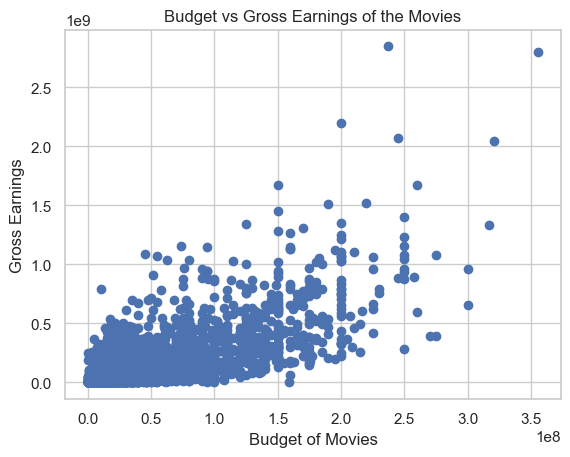

In [79]:
plt.scatter(x=data['budget'], y=data['gross'])
plt.title("Budget vs Gross Earnings of the Movies")
plt.ylabel("Gross Earnings")
plt.xlabel("Budget of Movies")
plt.grid(True)
plt.show()

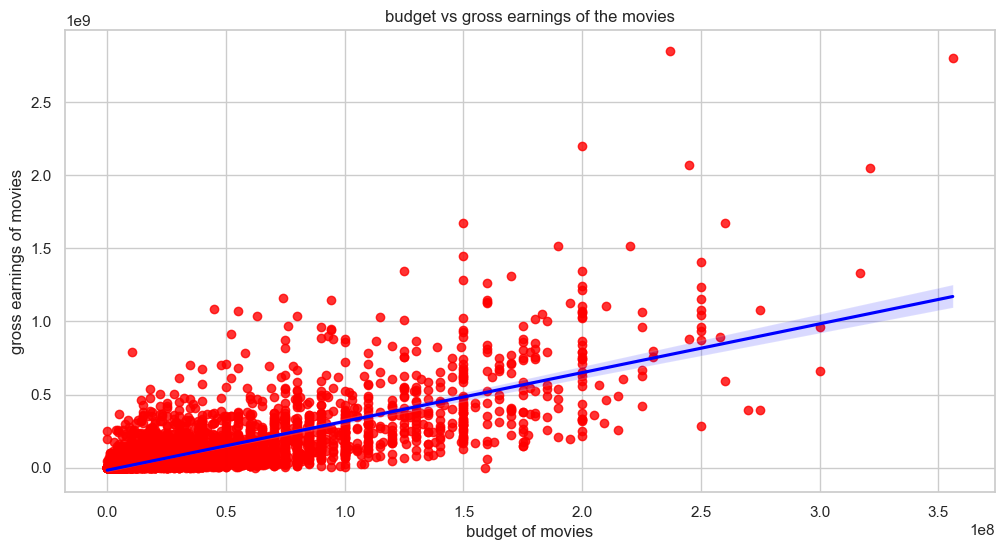

In [81]:
plt.figure(figsize=(12,6))
sns.set(style='whitegrid')
plt.title("budget vs gross earnings of the movies")
sns.regplot(x='budget', y='gross', data=data, scatter_kws={"color":"red"}, line_kws={"color":"blue"})
plt.xlabel('budget of movies')
plt.ylabel('gross earnings of movies')
plt.show()


In [83]:
df = data.select_dtypes(include=['number'])
df.corr(method='pearson') #pearson,kendall,spearman

,name,rating,genre,year,released_year,gross,budget,released,score,votes,director,writer,star,country,company,runtime,released_clean,Match
name,1.000000,-0.008638,0.014975,0.011715,0.011405,0.005574,0.023923,-0.009983,0.016971,0.013426,0.008816,0.009889,0.006995,-0.008822,0.009078,0.011579,-0.009892,-0.003163
rating,-0.008638,1.000000,0.073132,0.009135,0.007273,-0.107865,-0.175573,0.020303,0.001473,0.034041,0.020200,-0.004421,0.013462,0.081638,-0.031727,0.063779,0.019416,0.046668
genre,0.014975,0.073132,1.000000,-0.077453,-0.073969,-0.234934,-0.356405,0.030792,0.029140,-0.143854,-0.016599,0.006010,-0.005831,-0.036400,-0.071273,-0.051994,0.029994,0.110684
year,0.011715,0.009135,-0.077453,1.000000,0.997596,0.255777,0.328128,-0.002239,0.100527,0.220443,-0.021703,-0.008647,-0.028428,-0.074255,-0.013509,0.120306,-0.002370,0.018008
released_year,0.011405,0.007273,-0.073969,0.997596,1.000000,0.248977,0.321048,-0.006310,0.108188,0.216092,-0.020980,-0.008274,-0.028715,-0.084657,-0.018377,0.120084,-0.006384,0.060629
gross,0.005574,-0.107865,-0.234934,0.255777,0.248977,1.000000,0.740177,0.001078,0.187508,0.630195,-0.014947,-0.024001,-0.003382,0.091168,0.153778,0.245249,0.002630,-0.143214
budget,0.023923,-0.175573,-0.356405,0.328128,0.321048,0.740177,1.000000,0.014356,0.075841,0.441754,-0.012001,-0.039736,-0.020547,0.053757,0.172077,0.319960,0.016129,-0.179831
released,-0.009983,0.020303,0.030792,-0.002239,-0.006310,0.001078,0.014356,1.000000,0.042892,0.015343,-0.001394,-0.002643,0.014277,-0.022178,-0.012736,0.000729,0.999909,-0.110146
score,0.016971,0.001473,0.029140,0.100527,0.108188,0.187508,0.075841,0.042892,1.000000,0.411519,0.011338,0.021536,0.000483,-0.130905,0.001701,0.400706,0.043020,0.163787
votes,0.013426,0.034041,-0.143854,0.220443,0.216092,0.630195,0.441754,0.015343,0.411519,1.000000,-0.000261,0.000414,-0.020060,0.072724,0.131918,0.309149,0.016393,-0.078482


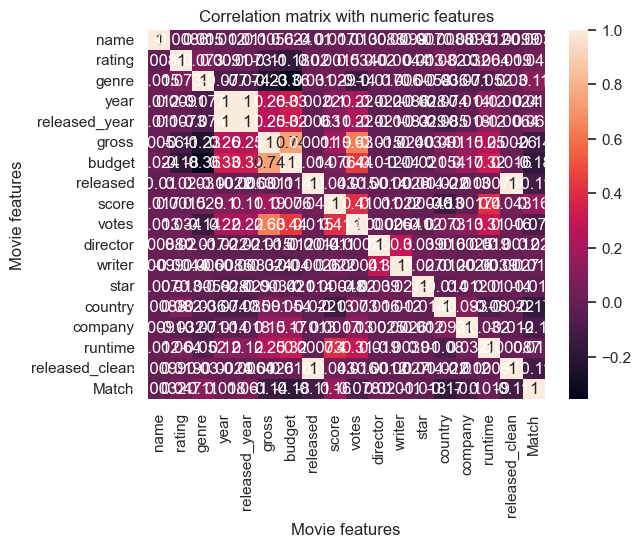

In [85]:
correlation_matrix = df.corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation matrix with numeric features")
plt.xlabel("Movie features")
plt.ylabel("Movie features")
plt.show()

In [87]:
df = data

In [89]:
df_numerized = data

In [91]:
for col_name in df_numerized.columns:
    if (df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes

df_numerized.head()

,name,rating,genre,year,released_year,gross,budget,released,score,votes,director,writer,star,country,company,runtime,released_clean,Match
5445,532,5,0,2009,2009,2.847246e+09,237000000.0,680,7.8,1100000.0,1147,1768,2305,55,2228,162.0,596,0
7445,534,5,0,2019,2019,2.797501e+09,356000000.0,170,8.4,903000.0,162,737,2212,55,1587,181.0,142,0
3045,6841,5,6,1997,1997,2.201647e+09,200000000.0,688,7.8,1100000.0,1147,1768,1574,55,2228,194.0,602,0
6663,5105,5,0,2015,2015,2.069522e+09,245000000.0,682,7.8,876000.0,1118,2539,517,55,1521,138.0,598,0
7244,535,5,0,2018,2018,2.048360e+09,321000000.0,179,8.4,897000.0,162,737,2212,55,1587,149.0,150,0


In [93]:
df.head()

,name,rating,genre,year,released_year,gross,budget,released,score,votes,director,writer,star,country,company,runtime,released_clean,Match
5445,532,5,0,2009,2009,2.847246e+09,237000000.0,680,7.8,1100000.0,1147,1768,2305,55,2228,162.0,596,0
7445,534,5,0,2019,2019,2.797501e+09,356000000.0,170,8.4,903000.0,162,737,2212,55,1587,181.0,142,0
3045,6841,5,6,1997,1997,2.201647e+09,200000000.0,688,7.8,1100000.0,1147,1768,1574,55,2228,194.0,602,0
6663,5105,5,0,2015,2015,2.069522e+09,245000000.0,682,7.8,876000.0,1118,2539,517,55,1521,138.0,598,0
7244,535,5,0,2018,2018,2.048360e+09,321000000.0,179,8.4,897000.0,162,737,2212,55,1587,149.0,150,0


In [95]:
copy_data.head()

,name,rating,genre,year,released_year,gross,budget,released,score,votes,director,writer,star,country,company,runtime,released_clean,Match
5445,532,5,0,2009,2009,2.847246e+09,237000000.0,680,7.8,1100000.0,1147,1768,2305,55,2228,162.0,596,0
7445,534,5,0,2019,2019,2.797501e+09,356000000.0,170,8.4,903000.0,162,737,2212,55,1587,181.0,142,0
3045,6841,5,6,1997,1997,2.201647e+09,200000000.0,688,7.8,1100000.0,1147,1768,1574,55,2228,194.0,602,0
6663,5105,5,0,2015,2015,2.069522e+09,245000000.0,682,7.8,876000.0,1118,2539,517,55,1521,138.0,598,0
7244,535,5,0,2018,2018,2.048360e+09,321000000.0,179,8.4,897000.0,162,737,2212,55,1587,149.0,150,0


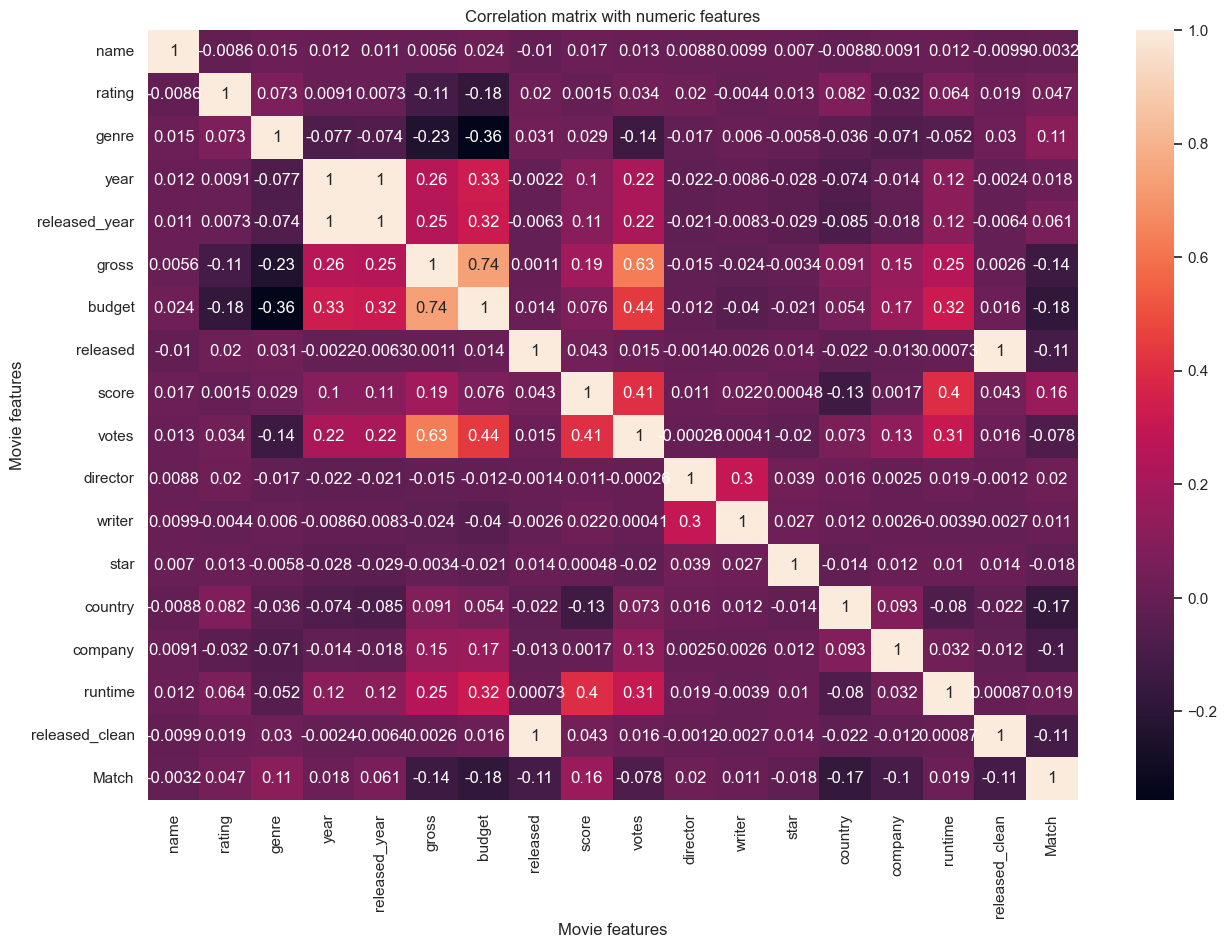

In [97]:
plt.figure(figsize=(15,10))
correlation_matrix = df_numerized.corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation matrix with numeric features")
plt.xlabel("Movie features")
plt.ylabel("Movie features")
plt.show()